# Analyse Event of G-ring Data

An earthquake in 2024 is analysed using the G-ring laser rotation data for the vertical component (thus only for Love waves), from a local MSEED file.

In [1]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt

from obspy import UTCDateTime
from sixdegrees.sixdegrees import sixdegrees

from sixdegrees.plots.plot_backazimuth_results import plot_backazimuth_results
from sixdegrees.plots.plot_velocities import plot_velocities
from sixdegrees.plots.plot_waveform_cc import plot_waveform_cc
from sixdegrees.plots.plot_cwt_all import plot_cwt_all


## Configurations

Define configurations in cell below.

In [2]:
config = {
    # Required time window parameters
    'tbeg': "2024-12-05 18:44:21",  # Start time
    'tend': "2024-12-05 20:44:21",  # End time

    # event
    'origin_time': "2024-12-05 18:44:26",
    'magnitude': 7.0,

    # station coordinates
    'station_lat': 49.1448,
    'station_lon': 12.8803,

    # SEED identifiers
    'seed': "XX.RLAS..",     # seed ID of output stream
    'rot_seed': ["XX.RLAS..BJZ"], # Rotation sensor seed ID
    'tra_seed': ["XX.RLAS..BHZ", "XX.RLAS..BHN", "XX.RLAS..BHE"],  # Translation sensor seed ID
    
    # rotate to ZNE
    'rotate_to_zne': False,

    # Data source
    'data_source': "mseed_file",  # "fdsn" | "sds" | "mseed_file"

    # Path to local mseed file
    'path_to_mseed_file': "./data/G_eventM7.0.mseed",

    # Remove responses
    'tra_remove_response': True,
    'rot_remove_response': True,

    # Path configurations
    'workdir': "./",            # Working directory
    'path_to_data_out': "./output/",  # Output directory

    # Project information
    'project': "G_Analysis",  # Project name
    
    # Optional parameters
    'verbose': True,            # Print detailed information
}

Alternatively load configuration from yaml file

In [3]:
# config = sixdegrees.load_from_yaml("config/config_G_M7.0_20241205.yml")

Setup a sixdegrees object

In [4]:
sd = sixdegrees(conf=config)

Store the configuration as a pickle file

In [5]:
filename = "./config/"+f"config_G_M{str(config['magnitude'])}_{config['tbeg'][:10].replace('-','')}"

# sd.store_as_yaml(config, filename)

This will load the data from the data source:
- local mseed file
- local sds system
- fdsn (online)

and trim it to the time window

In [6]:
sd.load_data(config['tbeg'], config['tend'], resample_rate=5)

-> fetching XX.RLAS..BHZ data from mseed file
-> fetching XX.RLAS..BHN data from mseed file
-> fetching XX.RLAS..BHE data from mseed file
3 Trace(s) in Stream:
XX.RLAS..BHZ | 2024-12-05T18:44:20.019999Z - 2024-12-05T20:44:22.019999Z | 20.0 Hz, 144041 samples
XX.RLAS..BHN | 2024-12-05T18:44:20.019999Z - 2024-12-05T20:44:22.019999Z | 20.0 Hz, 144041 samples
XX.RLAS..BHE | 2024-12-05T18:44:20.020000Z - 2024-12-05T20:44:22.020000Z | 20.0 Hz, 144041 samples
-> fetching XX.RLAS..BJZ data from mseed file
1 Trace(s) in Stream:
XX.RLAS..BJZ | 2024-12-05T18:44:19.981750Z - 2024-12-05T20:44:21.981750Z | 20.0 Hz, 144041 samples
-> resampling stream to 5 Hz
4 Trace(s) in Stream:
XX.RLAS..LHZ | 2024-12-05T18:44:20.019999Z - 2024-12-05T20:44:21.819999Z | 5.0 Hz, 36010 samples
XX.RLAS..LHN | 2024-12-05T18:44:20.019999Z - 2024-12-05T20:44:21.819999Z | 5.0 Hz, 36010 samples
XX.RLAS..LHE | 2024-12-05T18:44:20.020000Z - 2024-12-05T20:44:21.820000Z | 5.0 Hz, 36010 samples
XX.RLAS..LJZ | 2024-12-05T18:44:19

Get key information about the earthquake

In [7]:
try:
    ev = sd.get_event_info(
        origin_time=config['origin_time'],
        base_catalog="USGS",
        magnitude=config['magnitude']
    )
except:
    print("No event found")


Found event:
Origin time: 2024-12-05T18:44:21.110000Z
Magnitude: 7.0 mw
Location: 40.374°N, -125.022°E
Depth: 10.0 km
Epicentral Distance: 9264.46 km
Epicentral Distance: 83.3°
Backazimuth: 329.07°


Ensure that all traces of stream have the same sample size

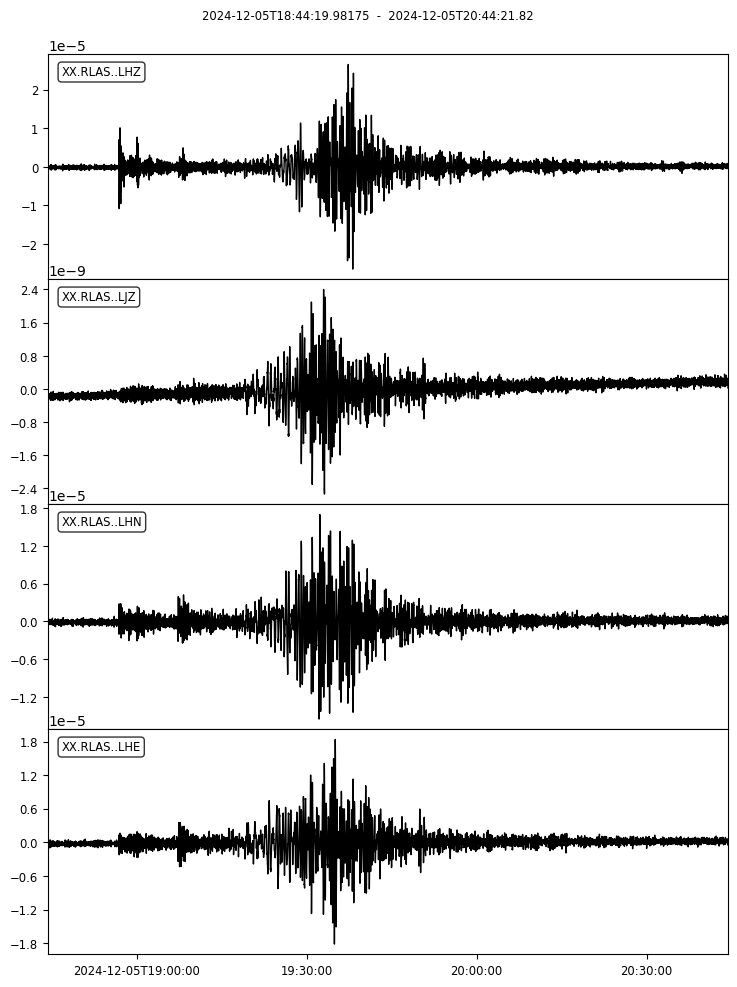

In [8]:
sd.st.plot(equal_scale=False);

In [9]:
sd.trim_stream(set_common=True, set_interpolate=False)

 -> trim_stream: window 2024-12-05T18:44:20.020000Z -> 2024-12-05T20:44:21.781750Z
    initial npts=[36010, 36010, 36010, 36010], rates=[5.0]
    final: starttimes={'2024-12-05T18:44:20.020000Z', '2024-12-05T18:44:20.019999Z', '2024-12-05T18:44:19.981750Z'}, npts={36010}, rates={5.0}


## Analysis

### Wavelet Comparsion

In [10]:
sd.trim(UTCDateTime(config['tbeg']) + 700, UTCDateTime(config['tend']) - 2500)

In [11]:
# First compute CWT for all components
cwt_results = {}
for comp in ['Z', 'N', 'E']:

    try:
        # Rotation components
        rot_data = sd.get_stream("rotation").select(channel=f"*{comp}")[0]
        component = rot_data.stats.channel
        cwt_results[f"{component}"] = sd.compute_cwt(
            rot_data.times(),
            rot_data.data,
            rot_data.stats.delta,
            normalize=True,
            fmin=0.01,
            fmax=1.0,
            dj=1/48
        )
    except Exception as e:
        print(f"No {comp} data for rotation")
        print(e)
    try:
        # Translation components
        acc_data = sd.get_stream("translation").select(channel=f"*{comp}")[0]
        component = acc_data.stats.channel
        cwt_results[f"{component}"] = sd.compute_cwt(
            acc_data.times(),
            acc_data.data,
            acc_data.stats.delta,
            normalize=True,
            fmin=0.01,
            fmax=1.0,
            dj=1/48
        )
    except:
        print(f"No {comp} data for ranslation")


No Z data for rotation
module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
No Z data for ranslation
No N data for rotation
list index out of range
No N data for ranslation
No E data for rotation
list index out of range
No E data for ranslation


In [12]:
# Then plot all components
try:
    fig = plot_cwt_all(
        rot=sd.get_stream("rotation").copy(),
        acc=sd.get_stream("translation").copy(),
        cwt_output=cwt_results,
        clog=True,
        fmax=1,
        fmin=0.01
    )
    del fig
except:
    print("No data to plot")



No data to plot


<Figure size 1500x0 with 0 Axes>

Frequency band to filter (this is applied to the stream object after being reset to raw stream)

In [13]:
sd.filter_data(fmin=0.01, fmax=0.1, output=False)

Apply polarity correction if needed. This is applied to the stream object that is processed. If raw is True, the polarity correction is applied to the raw stream too.

In [14]:
sd.polarity_stream(pol_dict={"HZ": 1, "JZ": 1}, raw=True)

-> polarity already applied. Exiting...


Let's cut to the main event to the interesting waveform section

In [15]:
sd.trim(UTCDateTime(config['tbeg']) + 700, UTCDateTime(config['tend']) - 2500)

Let's compare the waveforms of the rotation (red) and translational (black) components based on the cross-correlation in time windows

Theoretical P-arrival: 2024-12-05T18:56:48.159863Z
Theoretical S-arrival: 2024-12-05T19:07:09.518520Z


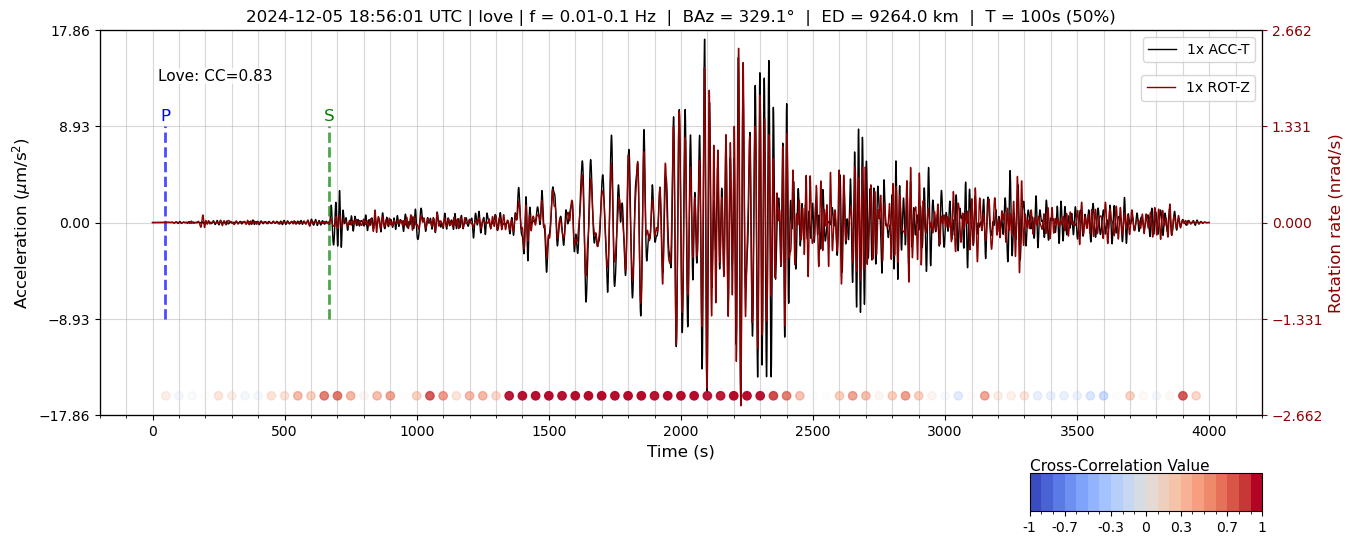

In [16]:
fig = plot_waveform_cc(
    sd_object=sd,
    baz=ev['backazimuth'],
    distance=ev['distance_km'],
    fmin=sd.fmin,
    fmax=sd.fmax,
    twin_sec=100,
    twin_overlap=0.5,
    wave_type='love',
    show_p_arrival=True,
    show_s_arrival=True
)

### Backazimuth Estimate

Compute the backazimuth estimates in time windows for Love waves

In [ ]:
baz_results = sd.compute_backazimuth(
    wave_type='love',
    baz_step=1,
    baz_win_sec=100,
    baz_win_overlap=0.5,
    out=True
)


Plot the results of the backazimuth estimation using the midpoint approach

baz_max = 314, baz_std = 33


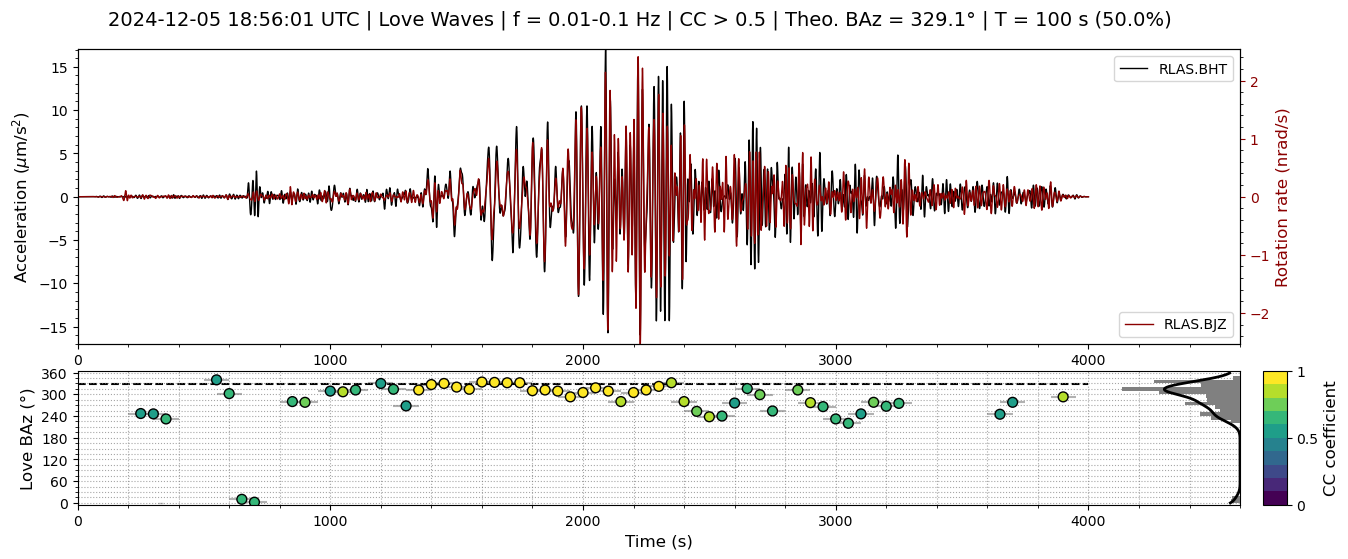

In [ ]:
fig = plot_backazimuth_results(
    sd, 
    baz_results,
    baz_theo=ev['backazimuth'],
    cc_threshold=0.5,
    cc_method='mid'
)

Plot the results of the backazimuth estimation using the maximum CC approach

baz_max = 309, baz_std = 24


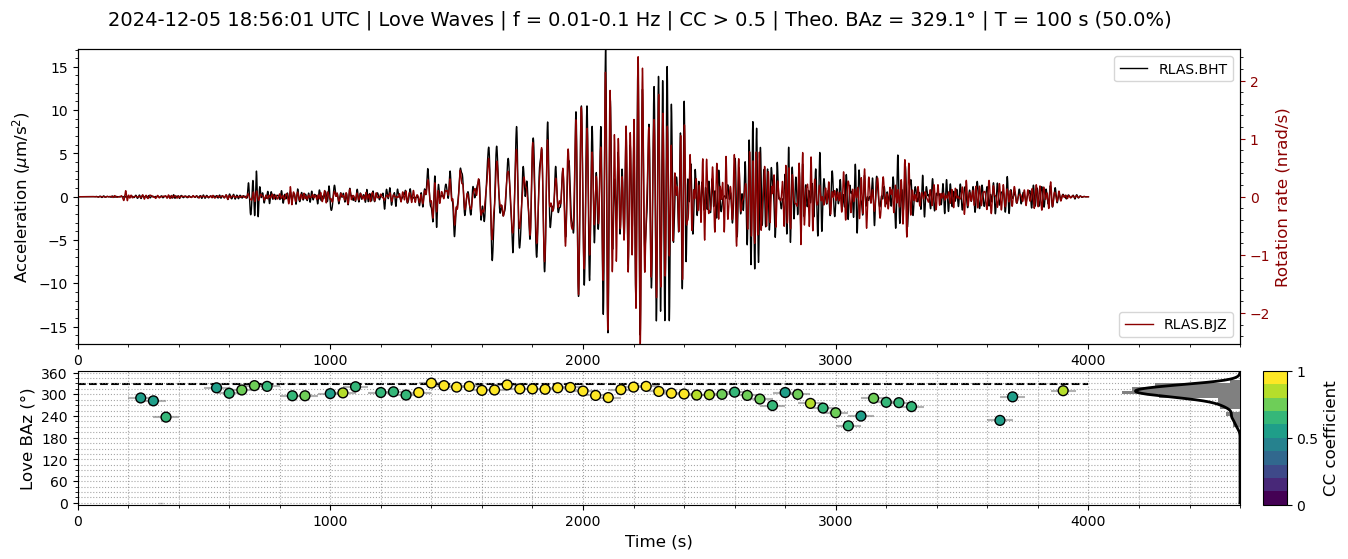

In [ ]:
fig = plot_backazimuth_results(
    sd, 
    baz_results,
    baz_theo=ev['backazimuth'],
    cc_threshold=0.5,
    cc_method='max'
)

### Analyse phase velocities

Compute the phase velocity estimates in time windows for Love waves using 

1) orthogonal distance regression (ODR)
2) RANdom SAmple Consensus regression (RANSAC)

In [ ]:
# Compute Love wave velocities
love_velocities = sd.compute_velocities(
    wave_type='love',
    win_time_s=50.0,
    overlap=0.5,
    cc_threshold=0.,
    method='odr',
    baz=ev['backazimuth']  # optional
)


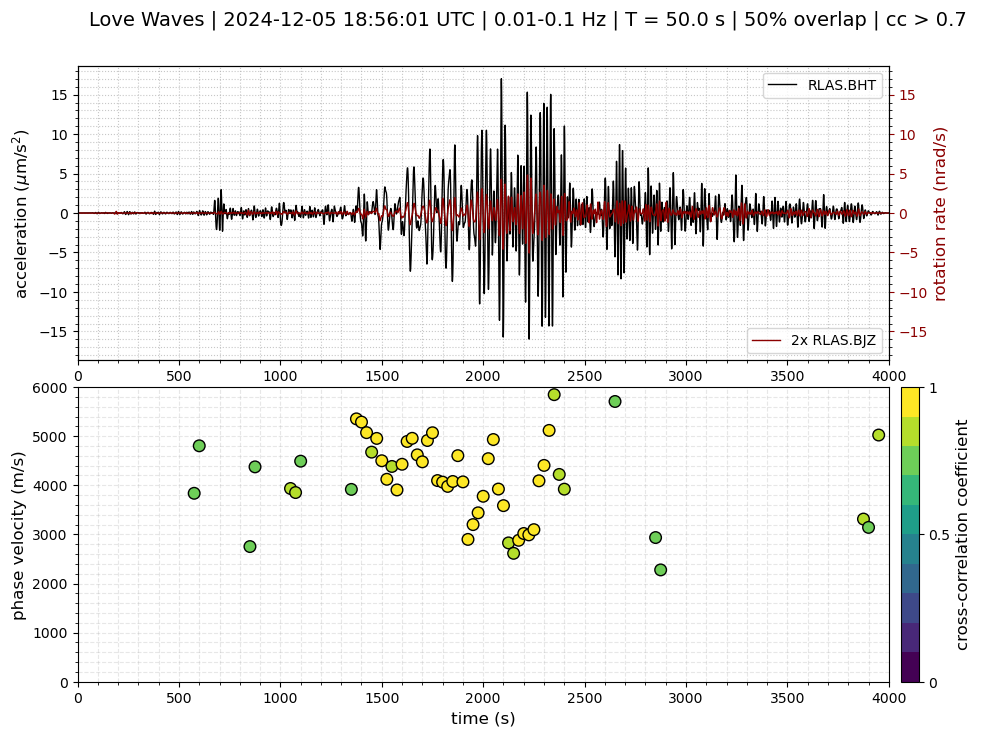

In [ ]:
fig = plot_velocities(
    sd,
    velocity_results=love_velocities,
    vmax=6000,  # optional
    minors=True, # optional
    cc_threshold=0.7,
)


In [ ]:
# Compute Love wave velocities
love_velocities = sd.compute_velocities(
    wave_type='love',
    win_time_s=50.0,
    overlap=0.5,
    cc_threshold=0.,
    method='ransac',
    baz=ev['backazimuth']  # optional
)

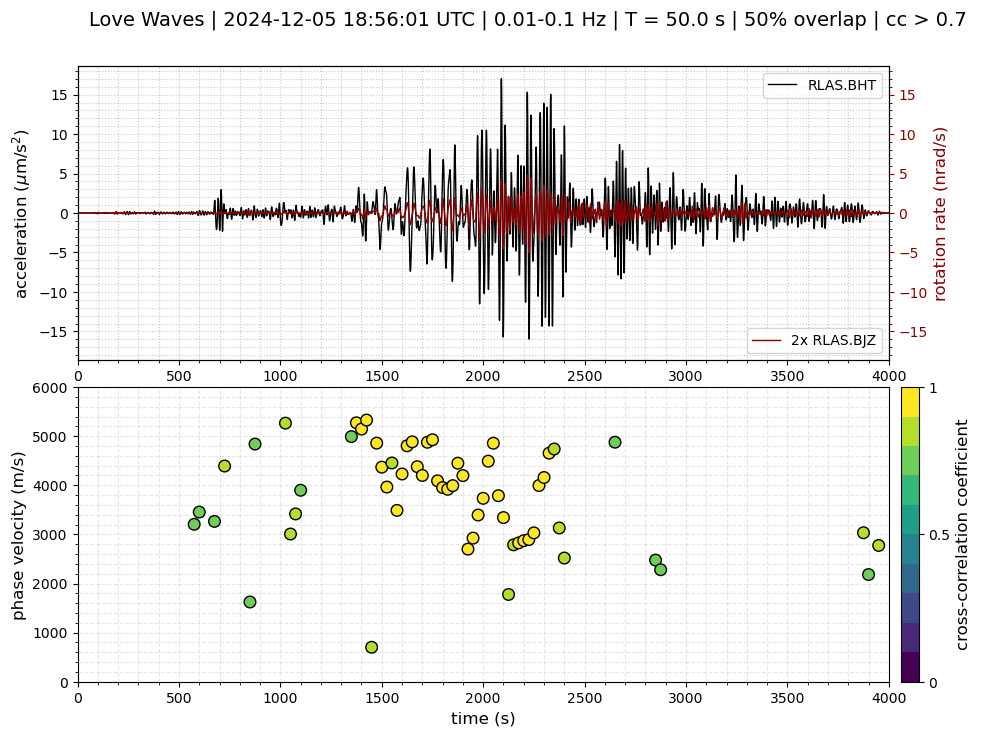

In [ ]:
fig = plot_velocities(
    sd,
    velocity_results=love_velocities,
    vmax=6000,  # optional
    minors=True, # optional
    cc_threshold=0.7,
)
